# Singapore Job Postings Salary Benchmarking Project

## Objective
Analyze salary data, clean outliers, and understand salary distribution trends in Singapore job postings.

## Salary Data Cleaning & Outlier Handling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [2]:
df = pd.read_csv("data/SGJobData.csv")
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [3]:
df.columns

Index(['categories', 'employmentTypes', 'metadata_expiryDate',
       'metadata_isPostedOnBehalf', 'metadata_jobPostId',
       'metadata_newPostingDate', 'metadata_originalPostingDate',
       'metadata_repostCount', 'metadata_totalNumberJobApplication',
       'metadata_totalNumberOfView', 'minimumYearsExperience',
       'numberOfVacancies', 'occupationId', 'positionLevels',
       'postedCompany_name', 'salary_maximum', 'salary_minimum', 'salary_type',
       'status_id', 'status_jobStatus', 'title', 'average_salary'],
      dtype='object')

In [4]:
#Date columns need explicit parsing — do this early so date arithmetic works later:

df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])


## Missing Value Check

No missing values were found in the salary column. Therefore, no imputation or data filling was required.

In [5]:
# Quick stats on the salary columns
df[['salary_minimum', 'salary_maximum', 'average_salary']].describe().round(0)

,salary_minimum,salary_maximum,average_salary
count,1048585.0,1048585.0,1048585.0
mean,3815.0,5724.0,4769.0
std,3172.0,50184.0,25478.0
min,0.0,0.0,0.0
25%,2500.0,3300.0,2900.0
50%,3000.0,4500.0,3800.0
75%,4500.0,6500.0,5500.0
max,350000.0,25330000.0,12666400.0


In [6]:
df["salary"] = (df["salary_minimum"] + df["salary_maximum"]) / 2

In [7]:
df["salary"].describe()

count    1.048585e+06
mean     4.769445e+03
std      2.547809e+04
min      0.000000e+00
25%      2.900000e+03
50%      3.800000e+03
75%      5.500000e+03
max      1.266640e+07
Name: salary, dtype: float64

In [8]:
#this is used to count missing values in the column
df["salary"].isnull().sum()

0

In [9]:
print("Before max:", df["salary"].max())

Before max: 12666400.0


In [10]:
lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df_clean = df[(df["salary"] >= lower) & (df["salary"] <= upper)]

In [11]:
print("After max:", df_clean["salary"].max())

After max: 16666.5


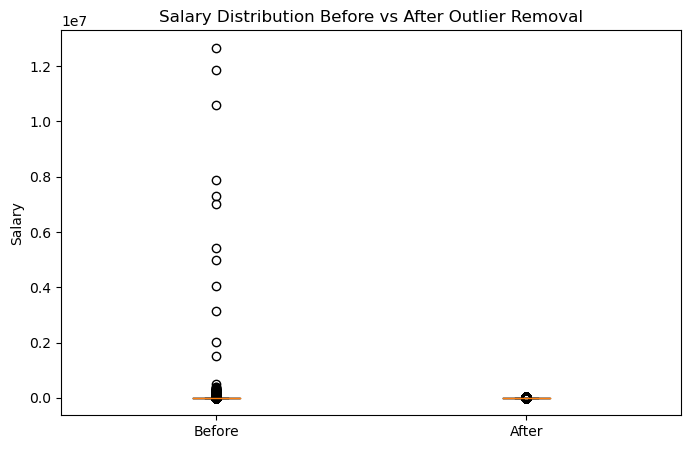

In [12]:
plt.figure(figsize=(8,5))

plt.boxplot([df["salary"], df_clean["salary"]], labels=["Before", "After"])

plt.title("Salary Distribution Before vs After Outlier Removal")
plt.ylabel("Salary")
plt.show()

## Extract primary category from the 'categories' column

In [13]:
def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df['primary_category'] = df['categories'].apply(extract_first_category)
print(df['primary_category'].value_counts().head(10))


Admin / Secretarial                 102719
Information Technology              100142
Engineering                          99675
Accounting / Auditing / Taxation     78648
Building and Construction            74014
Customer Service                     64865
F&B                                  59678
Banking and Finance                  46635
Logistics / Supply Chain             44391
Sales / Retail                       37313
Name: primary_category, dtype: int64


In [14]:
print(f'Unique categories: {df["primary_category"].nunique()}')
print()

Unique categories: 43



In [15]:
df_clean = df[df["salary"].notnull()].copy()

---
## Salary Benchmark

In [16]:
# Always look at a few sample rows before doing anything
df_clean.head(3)

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary,salary,primary_category
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0,2400.0,Environment / Health
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0,4750.0,Information Technology
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0,4200.0,Repair and Maintenance


In [17]:
df = df_clean.copy()

before = len(df)
df = df.dropna(subset=['title'])
after  = len(df)

print(f'Dropped : {before - after:,} rows')
print(f'Remaining: {after:,} rows')

Dropped : 3,988 rows
Remaining: 1,044,597 rows


In [18]:
print('salary_type distribution:')
print(df['salary_type'].value_counts(dropna=False))

before = len(df)
df = df[df['salary_type'] == 'Monthly']
after  = len(df)

print(f'\nDropped : {before - after:,} rows')
print(f'Remaining: {after:,} rows')

salary_type distribution:
Monthly    1044597
Name: salary_type, dtype: int64

Dropped : 0 rows
Remaining: 1,044,597 rows


In [19]:
LEVEL_ORDER = [
    'Fresh/entry level',
    'Non-executive',
    'Junior Executive',
    'Executive',
    'Professional',
    'Senior Executive',
    'Manager',
    'Middle Management',
    'Senior Management',
]

df['positionLevels'] = pd.Categorical(
    df['positionLevels'],
    categories=LEVEL_ORDER,
    ordered=True
)

print('positionLevels distribution (in correct order):')
print(df['positionLevels'].value_counts().reindex(LEVEL_ORDER))

positionLevels distribution (in correct order):
Fresh/entry level    118661
Non-executive        131608
Junior Executive     167656
Executive            253701
Professional         112208
Senior Executive     100459
Manager              110122
Middle Management     27375
Senior Management     22807
Name: positionLevels, dtype: int64


In [20]:
print('Before clip — values > 20:')
print(df[df['minimumYearsExperience'] > 20]['minimumYearsExperience'].value_counts().sort_index())

df['minimumYearsExperience'] = df['minimumYearsExperience'].clip(upper=20)

print('\nAfter clip — max value:', df['minimumYearsExperience'].max())

Before clip — values > 20:
21      5
22     21
23      5
24      2
25    110
26      4
27      4
28      3
29      3
30     79
31      4
32      2
33      3
35      6
38      1
40      2
47      1
50      3
55      2
56      2
58      1
59      2
60      1
61      2
62      1
63      1
76      1
87      2
88      2
Name: minimumYearsExperience, dtype: int64

After clip — max value: 20


In [21]:
bins   = [-1, 0, 2, 5, 9, 20]
labels = ['0 yr', '1-2 yrs', '3-5 yrs', '6-9 yrs', '10+ yrs']

df['exp_band'] = pd.cut(
    df['minimumYearsExperience'],
    bins=bins,
    labels=labels
)

print('Experience band distribution:')
print(df['exp_band'].value_counts().sort_index())

Experience band distribution:
0 yr       114451
1-2 yrs    483994
3-5 yrs    349923
6-9 yrs     60426
10+ yrs     35803
Name: exp_band, dtype: int64


In [22]:
# ── Step 9a: Compute Q1, Q3, IQR per positionLevel ──────────────────────────
grp_stats = (
    df.groupby('positionLevels', observed=True)['average_salary']
    .agg(
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

grp_stats['IQR']   = grp_stats['Q3'] - grp_stats['Q1']
grp_stats['lower'] = (grp_stats['Q1'] - 1.5 * grp_stats['IQR']).clip(lower=500)
grp_stats['upper'] =  grp_stats['Q3'] + 1.5 * grp_stats['IQR']

print('IQR fences per position level:')
print(grp_stats.to_string(index=False))

IQR fences per position level:
   positionLevels     Q1      Q3    IQR  lower   upper
Fresh/entry level 2000.0  3250.0 1250.0  500.0  5125.0
    Non-executive 2200.0  3500.0 1300.0  500.0  5450.0
 Junior Executive 2650.0  3750.0 1100.0 1000.0  5400.0
        Executive 3150.0  4500.0 1350.0 1125.0  6525.0
     Professional 4050.0  8750.0 4700.0  500.0 15800.0
 Senior Executive 4000.0  6500.0 2500.0  500.0 10250.0
          Manager 4650.0  8000.0 3350.0  500.0 13025.0
Middle Management 4000.0  9500.0 5500.0  500.0 17750.0
Senior Management 7750.0 13500.0 5750.0  500.0 22125.0


In [23]:
# ── Step 9b: Merge fences back onto the main dataframe ──────────────────────
df = df.merge(
    grp_stats[['positionLevels', 'lower', 'upper']],
    on='positionLevels',
    how='left'
)

# ── Step 9c: Keep only rows within their group's fences ─────────────────────
before = len(df)

df = df[
    (df['average_salary'] >= df['lower']) &
    (df['average_salary'] <= df['upper'])
]

after = len(df)

print(f'Removed : {before - after:,} outlier rows')
print(f'Remaining: {after:,} rows')

# ── Step 9d: Drop the helper columns ────────────────────────────────────────
df = df.drop(columns=['lower', 'upper'])

Removed : 60,282 outlier rows
Remaining: 984,315 rows


In [24]:
# Verify the salary range looks clean now
print('Salary stats after outlier removal:')
print(df.groupby('positionLevels', observed=True)['average_salary'].agg(['min', 'median', 'max']).round(0))

Salary stats after outlier removal:
                      min  median      max
positionLevels                            
Fresh/entry level   500.0  2500.0   5125.0
Non-executive       500.0  2692.0   5450.0
Junior Executive   1000.0  3050.0   5400.0
Executive          1125.0  3750.0   6500.0
Professional        500.0  6000.0  15800.0
Senior Executive    500.0  5000.0  10250.0
Manager             500.0  6000.0  13004.0
Middle Management   500.0  6500.0  17750.0
Senior Management   650.0  9100.0  22125.0


In [25]:
# ── Step 10a: Recompute Q1, Q3, IQR on clean data ───────────────────────────
# Group by both positionLevels AND category for a finer benchmark
zone_stats = (
    df.groupby(['positionLevels', 'primary_category'], observed=True)['average_salary']
    .agg(
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

zone_stats['IQR']         = zone_stats['Q3'] - zone_stats['Q1']
zone_stats['fence_lower'] = (zone_stats['Q1'] - 1.5 * zone_stats['IQR']).clip(lower=0)
zone_stats['fence_upper'] =  zone_stats['Q3'] + 1.5 * zone_stats['IQR']

# Merge back
df = df.merge(
    zone_stats[['positionLevels', 'primary_category', 'Q1', 'Q3', 'IQR', 'fence_lower', 'fence_upper']],
    on=['positionLevels', 'primary_category'],
    how='left'
)

print(f'Zone stats merged. Sample:')
df[['positionLevels', 'primary_category', 'average_salary', 'Q1', 'Q3', 'IQR']].head(3)

Zone stats merged. Sample:


,positionLevels,primary_category,average_salary,Q1,Q3,IQR
0,Executive,Environment / Health,2400.0,3250.0,4500.0,1250.0
1,Executive,Information Technology,4750.0,3750.0,5500.0,1750.0
2,Senior Executive,Repair and Maintenance,4200.0,3500.0,4500.0,1000.0


In [28]:
# ── Step 10b: Assign competitive_zone label ──────────────────────────────────
def assign_zone(row):
    s  = row['average_salary']
    q1 = row['Q1']
    q3 = row['Q3']
    fl = row['fence_lower']
    fu = row['fence_upper']

    if s < fl:
        return 'Critically Low'
    elif s < q1:
        return 'Below Market'
    elif s <= q3:
        return 'Competitive'
    elif s <= fu:
        return 'Above Market'
    else:
        return 'Significantly Over'

df['competitive_zone'] = df.apply(assign_zone, axis=1)

print('Competitive zone distribution:')
print(df['competitive_zone'].value_counts())

Competitive zone distribution:
Competitive           533936
Below Market          222103
Above Market          199420
Significantly Over     24556
Critically Low          4300
Name: competitive_zone, dtype: int64


In [ ]:
# Cross-tab: how do zones distribute across position levels?
zone_order = ['Critically Low', 'Below Market', 'Competitive', 'Above Market', 'Significantly Over']

cross = pd.crosstab(
    df['positionLevels'],
    df['competitive_zone'],
    normalize='index'
).round(3)

# Reorder columns
cross = cross[[c for c in zone_order if c in cross.columns]]
print('Zone % per position level:')
print(cross)

Zone % per position level:
competitive_zone   Critically Low  Below Market  Competitive  Above Market  \
positionLevels                                                               
Fresh/entry level           0.011         0.220        0.543         0.207   
Non-executive               0.003         0.232        0.531         0.221   
Junior Executive            0.004         0.223        0.549         0.211   
Executive                   0.004         0.230        0.539         0.203   
Professional                0.003         0.229        0.537         0.175   
Senior Executive            0.001         0.227        0.548         0.200   
Manager                     0.000         0.225        0.545         0.205   
Middle Management           0.014         0.206        0.552         0.169   
Senior Management           0.021         0.182        0.593         0.177   

competitive_zone   Significantly Over  
positionLevels                         
Fresh/entry level               0.

In [ ]:
df['posting_date'] = pd.to_datetime(
    df['metadata_originalPostingDate'],
    errors='coerce'   # invalid dates become NaT instead of crashing
)

# year_month string (e.g. '2023-04') for easy grouping
df['year_month'] = df['posting_date'].dt.to_period('M').astype(str)

print('Date range:', df['posting_date'].min(), '→', df['posting_date'].max())
print()
print('Postings per month (last 10):')
print(df['year_month'].value_counts().sort_index().tail(10))

Date range: 2022-10-03 00:00:00 → 2024-05-29 00:00:00

Postings per month (last 10):
2023-08    78626
2023-09    72050
2023-10    75655
2023-11    67998
2023-12    57465
2024-01    76081
2024-02    64804
2024-03    74618
2024-04    76328
2024-05    67964
Name: year_month, dtype: int64


In [ ]:
COLS_TO_DROP = [
    'occupationId',
    'status_id',
    'metadata_expiryDate',
    'metadata_newPostingDate',
    'metadata_jobPostId',
    'metadata_originalPostingDate',    # replaced by 'posting_date'
    'salary_type',                     # all rows are Monthly now
]

df = df.drop(columns=COLS_TO_DROP, errors='ignore')

print('Remaining columns:')
for col in df.columns:
    print(f'  {col}')

Remaining columns:
  employmentTypes
  metadata_isPostedOnBehalf
  metadata_repostCount
  metadata_totalNumberJobApplication
  metadata_totalNumberOfView
  minimumYearsExperience
  numberOfVacancies
  positionLevels
  postedCompany_name
  salary_maximum
  salary_minimum
  status_jobStatus
  title
  average_salary
  salary
  primary_category
  exp_band
  Q1
  Q3
  IQR
  fence_lower
  fence_upper
  competitive_zone
  posting_date
  year_month
  midpoint_salary


In [ ]:
# ── Final checks ────────────────────────────────────────────────────────────
print('=== FINAL DATASET SUMMARY ===')
print(f'Total rows      : {len(df):,}')
print(f'Total columns   : {df.shape[1]}')
print()

print('Null counts in key columns:')
key_cols = ['average_salary', 'positionLevels', 'primary_category', 'postedCompany_name',
            'competitive_zone', 'Q1', 'Q3']
print(df[key_cols].isnull().sum())
print()

print('Salary range:')
print(f'  Min: ${df["average_salary"].min():,.0f}')
print(f'  Max: ${df["average_salary"].max():,.0f}')
print(f'  Median: ${df["average_salary"].median():,.0f}')
print()

print('Competitive zone distribution:')
print(df['competitive_zone'].value_counts())

=== FINAL DATASET SUMMARY ===
Total rows      : 981,318
Total columns   : 26

Null counts in key columns:
average_salary        0
positionLevels        0
primary_category      0
postedCompany_name    0
competitive_zone      0
Q1                    0
Q3                    0
dtype: int64

Salary range:
  Min: $500
  Max: $16,650
  Median: $3,750

Competitive zone distribution:
Competitive           532739
Below Market          221394
Above Market          198736
Significantly Over     24087
Critically Low          4362
Name: competitive_zone, dtype: int64


In [ ]:
# ── Save to Parquet ──────────────────────────────────────────────────────────
CLEAN_PATH = 'sg_jobs_salary.parquet'
df.to_parquet(CLEAN_PATH, index=False)

# Confirm file was written
size_mb = os.path.getsize(CLEAN_PATH) / 1_000_000
print(f'Saved to  : {CLEAN_PATH}')
print(f'File size : {size_mb:.1f} MB')

# Quick reload test — make sure it reads back correctly
df_test = pd.read_parquet(CLEAN_PATH)
print(f'Reload check: {len(df_test):,} rows × {df_test.shape[1]} columns  ✓')
print()
print('Column dtypes after reload:')
print(df_test.dtypes)

Saved to  : sg_jobs_salary.parquet
File size : 66.1 MB
Reload check: 981,318 rows × 26 columns  ✓

Column dtypes after reload:
employmentTypes                               object
metadata_isPostedOnBehalf                       bool
metadata_repostCount                           int64
metadata_totalNumberJobApplication             int64
metadata_totalNumberOfView                     int64
minimumYearsExperience                         int64
numberOfVacancies                              int64
positionLevels                              category
postedCompany_name                            object
salary_maximum                                 int64
salary_minimum                                 int64
status_jobStatus                              object
title                                         object
average_salary                               float64
salary                                       float64
primary_category                              object
exp_band                 

In [ ]:
# IMPORTANT: assumed that df_clean contains the following, processed by the team

# df_clean contains:
# - primary_category (parsed)
# - positionLevels
# - minimumYearsExperience
# - outliers already handled
# - filtered dataset (agency/direct based on team decision)

df.head()

,employmentTypes,metadata_isPostedOnBehalf,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,positionLevels,postedCompany_name,salary_maximum,...,exp_band,Q1,Q3,IQR,fence_lower,fence_upper,competitive_zone,posting_date,year_month,midpoint_salary
0,Permanent,False,2,5,151,0,1,Executive,WORKSTONE PTE. LTD.,2800,...,0 yr,3250.0,4500.0,1250.0,1375.0,6375.0,Below Market,2023-03-30,2023-03,2400.0
1,Permanent,False,0,0,55,2,2,Executive,TRUST RECRUIT PTE. LTD.,5500,...,1-2 yrs,3750.0,5500.0,1750.0,1125.0,8125.0,Competitive,2023-04-08,2023-04,4750.0
2,Full Time,False,0,7,99,3,1,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,...,3-5 yrs,3500.0,4500.0,1000.0,2000.0,6000.0,Competitive,2023-04-08,2023-04,4200.0
3,Permanent,False,0,6,113,8,1,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,...,6-9 yrs,5600.0,8500.0,2900.0,1250.0,12850.0,Competitive,2023-04-08,2023-04,7500.0
4,Full Time,False,0,3,99,2,3,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,...,1-2 yrs,2100.0,2900.0,800.0,900.0,4100.0,Competitive,2023-04-08,2023-04,2900.0


In [29]:
# first we calculate the midpoint_salary (midpoint between minimum and maximum salary)
# this is needed because job postings provides a salary range instead of a single number
# aim is to convert each job into a single comparable value
# make use of the midpoint between minimum and maximum salary to avoid biasing towards the minimum/maximum salary
df["midpoint_salary"] = (
    df["salary_minimum"] + df["salary_maximum"]
) / 2

In [30]:
# Groups jobs by: Category (e.g. IT, Finance), Position level (e.g., Executive, Manager), Years of experience
# then compute the median salary for each group
# note that median is used instead of mean because high paying outliers can distort averages
# median is a good representation of the typical market salary for each group
# therefore we recommend salary based on the median of comparable roles (same category, level, and experience)
salary_table = df.groupby(
    ["primary_category", "positionLevels", "minimumYearsExperience"]
)["midpoint_salary"].median().reset_index()
salary_table

,primary_category,positionLevels,minimumYearsExperience,midpoint_salary
0,Accounting / Auditing / Taxation,Fresh/entry level,0,2550.0
1,Accounting / Auditing / Taxation,Fresh/entry level,1,2500.0
2,Accounting / Auditing / Taxation,Fresh/entry level,2,2800.0
3,Accounting / Auditing / Taxation,Fresh/entry level,3,3200.0
4,Accounting / Auditing / Taxation,Fresh/entry level,4,3575.0
...,...,...,...,...
8122,Wholesale Trade,Senior Management,16,NaN
8123,Wholesale Trade,Senior Management,17,NaN
8124,Wholesale Trade,Senior Management,18,NaN
8125,Wholesale Trade,Senior Management,19,NaN


In [31]:
#create a function to get the midpoint_salary based on category, level and experience
def get_salary(category, level, experience):

    result = salary_table[
        (salary_table["primary_category"] == category) &
        (salary_table["positionLevels"] == level) &
        (salary_table["minimumYearsExperience"] == experience)
    ]

    if result.empty:
        return "No data available"

    return result["midpoint_salary"].values[0]

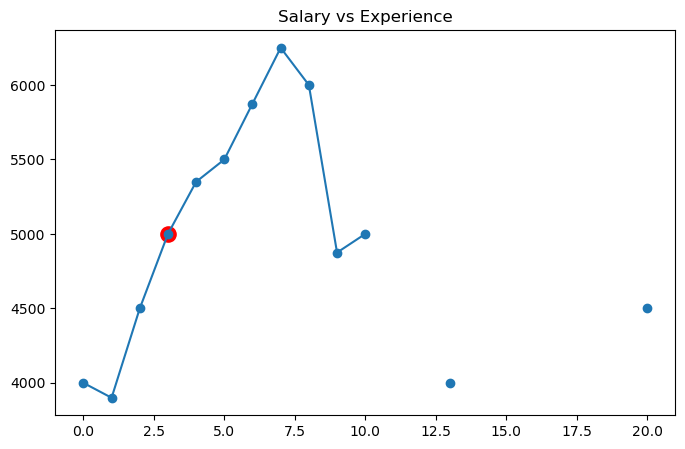

In [40]:
# visualize the relationship between experience and salary
# we want to show the salary structure of the market
category = "Information Technology"
level = "Executive"
experience = 3

trend = salary_table[
    (salary_table["primary_category"] == category) &
    (salary_table["positionLevels"] == level)
]

plt.figure(figsize=(8,5))
plt.plot(trend["minimumYearsExperience"], trend["midpoint_salary"], marker="o")

plt.scatter(
    experience,
    get_salary(category, level, experience),
    color="red",
    s=120
)

plt.title("Salary vs Experience")
plt.show()

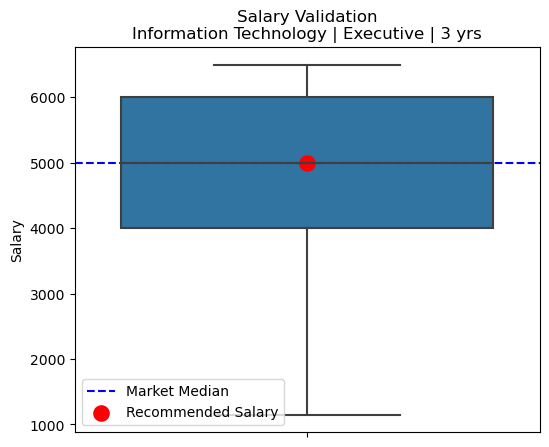

In [39]:
# Salary Validation Chart
# given one specific job context
# - the boxplot should show where most market salaries lies
# - what the median is
# - where our recommendation sits
# this chart is use to answer whether the recommended salary is reasonable and competitive in the market

category = "Information Technology"
level = "Executive"
experience = 3

# Selecting only job postings that match a specific role context
subset = df[
    (df["primary_category"] == category) &
    (df["positionLevels"] == level) &
    (df["minimumYearsExperience"] == experience)
]

# Market median (this is your recommended value logic)
recommended_salary = subset["midpoint_salary"].median()

plt.figure(figsize=(6,5))

# Boxplot = market distribution
sns.boxplot(y=subset["midpoint_salary"])

# Add market median line
plt.axhline(
    recommended_salary,
    color="blue",
    linestyle="--",
    label="Market Median"
)

# Add recommended salary point (same here, but explicit)
plt.scatter(
    0,
    recommended_salary,
    color="red",
    s=120,
    label="Recommended Salary"
)

plt.title(f"Salary Validation\n{category} | {level} | {experience} yrs")
plt.ylabel("Salary")
plt.legend()
plt.show()